téléchargement de la dataset fusionnée 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cpu_full_dataset.csv")
df.head()


,timestamp,value,serveur_id
0,2014-02-14 14:30:00,0.132,24ae8d
1,2014-02-14 14:35:00,0.134,24ae8d
2,2014-02-14 14:40:00,0.134,24ae8d
3,2014-02-14 14:45:00,0.134,24ae8d
4,2014-02-14 14:50:00,0.134,24ae8d


Indexation 
Transformation de la colonne timestamp en format datetime et de la définir comme index du DataFrame afin de pouvoir utiliser les fonctionnalités spécifiques aux séries temporelles

In [2]:

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['serveur_id', 'timestamp'])
df = df.set_index('timestamp')
df.head()


,value,serveur_id
timestamp,,
2014-02-14 14:30:00,0.132,24ae8d
2014-02-14 14:35:00,0.134,24ae8d
2014-02-14 14:40:00,0.134,24ae8d
2014-02-14 14:45:00,0.134,24ae8d
2014-02-14 14:50:00,0.134,24ae8d


Séparation des données en deux pipelines :
    df_features :utilisé pour l'entraînement du modèle (avec filtrage et transformation pour améliorer les features)
    df_original : utilisé pour la détection d'anomalies afin de préserver les comportements anormaux

Cette approche permet d’éviter que le nettoyage des données n’affecte la détection des anomalies.

In [3]:
df_original = df.copy()
df_features = df.copy()

La Validation de l'Isolement — Double Tri des Serveurs

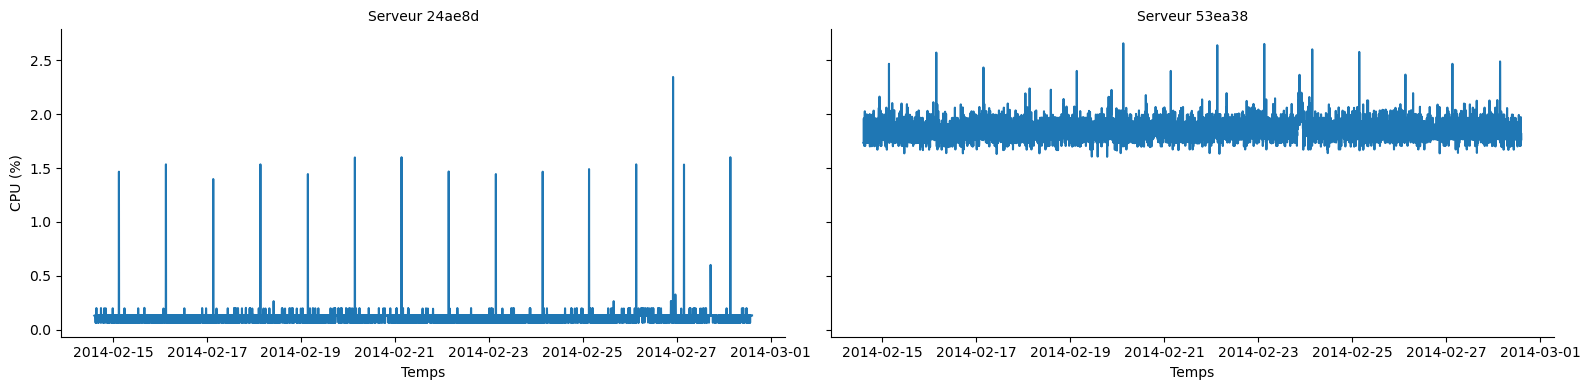

In [4]:
df_features = df_features.reset_index()  
servers = df_features['serveur_id'].unique()[:2]
df_plot = df_features[df_features['serveur_id'].isin(servers)]
g = sns.FacetGrid(df_plot, col='serveur_id', height=4, aspect=2)
g.map(plt.plot, 'timestamp', 'value')  
g.set_titles("Serveur {col_name}")
g.set_axis_labels("Temps", "CPU (%)")
plt.show()

>Isolement des serveurs : Chaque graphique montre un serveur distinct. Le tri par serveur_id et timestamp garantit que les features temporelles restent cohérentes par serveur.

PARTIE FEATURES

Filtre de hampel:pour détecter et corriger les valeurs aberrantes dans la série temporelle et les remplacer les anomalies par des valeurs normales (médiane)

In [5]:
def hampel_filter(series, window_size=5, n_sigmas=3):
    median = series.rolling(window_size).median()
    diff = np.abs(series - median)
    mad = diff.rolling(window_size).median()
    
    threshold = n_sigmas * mad
    outliers = diff > threshold
    
    series[outliers] = median[outliers]
    return series
df_features["value_filtered"] = df_features.groupby("serveur_id")["value"] \
    .transform(lambda x: hampel_filter(x))

Transformation logarithmique pour rendre les séries plus stationnaires 

In [6]:
df_features["value_log"] = np.log1p(df_features["value"])

Rolling Window
Calcul de la moyenne mobile des 5 derniéres observations afin de mieux observer la tendances d'utilisation du cpu

In [7]:
df_features['moyenne_mobile_5'] = df_features.groupby('serveur_id')['value_log'].transform(lambda x: x.rolling(5).mean())
df_features.head(5)

,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5
0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN
2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN
3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN
4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398


calcul de la moyenne mobile des 10 derniéres observations

In [8]:
df_features["rolling_mean_10"] = df_features.groupby("serveur_id")["value_log"].transform(lambda x: x.rolling(10).mean())


 Le Lissage et la Tendance — Moyenne Mobile

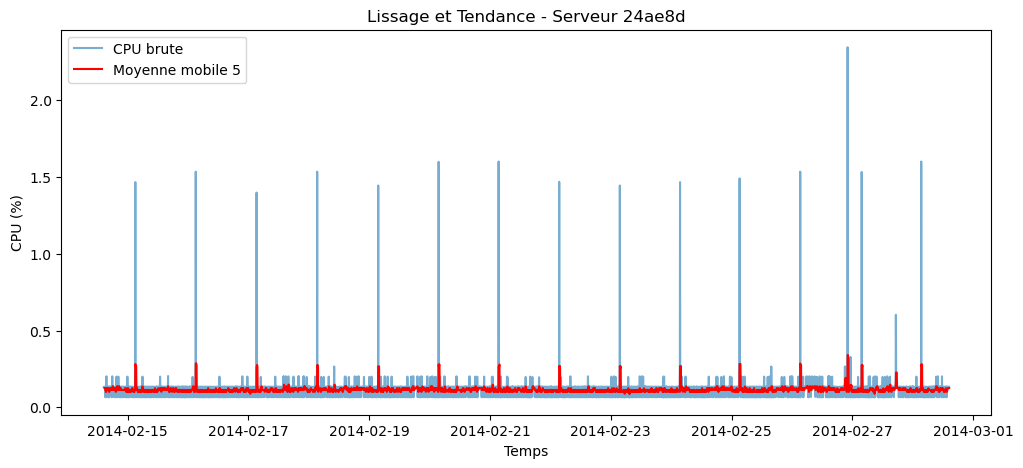

In [9]:
import matplotlib.pyplot as plt

# Choisir un serveur pour la visualisation
server_id = df_features['serveur_id'].unique()[0]
df_server = df_features[df_features['serveur_id'] == server_id]

plt.figure(figsize=(12,5))
plt.plot(df_server['timestamp'], df_server['value'], label='CPU brute', alpha=0.6)
plt.plot(df_server['timestamp'], df_server['moyenne_mobile_5'], label='Moyenne mobile 5', color='red')
plt.title(f"Lissage et Tendance - Serveur {server_id}")
plt.xlabel("Temps")
plt.ylabel("CPU (%)")
plt.legend()
plt.show()

>Lissage et tendance : La courbe rouge (moyenne mobile) élimine les micro-fluctuations et révèle la tendance générale de la charge CPU.

Lagging
Création  d'une variable cible correspondant à la valeur future du CPU, afin de transformer la série temporelle en problème de régression supervisée pour la modélisation prédictive.

In [10]:
df_features["target"] = df_features.groupby("serveur_id")["value_log"].shift(-1).rolling(3).mean()
df_features.head(5)

,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target
0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN,NaN,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,NaN
2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751
3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751
4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398,NaN,0.125751


les features qu'on peut ajouter pour améliorer la dataset pour machine learning 

Lag features:

In [11]:
df_features["lag_1"] = df_features.groupby("serveur_id")["value_log"].shift(1)
df_features["lag_2"] = df_features.groupby("serveur_id")["value_log"].shift(2)
df_features["lag_3"] = df_features.groupby("serveur_id")["value_log"].shift(3)
df_features["lag_5"] = df_features.groupby("serveur_id")["value_log"].shift(5)
df_features["lag_10"] = df_features.groupby("serveur_id")["value_log"].shift(10)
df_features.head(5)

,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target,lag_1,lag_2,lag_3,lag_5,lag_10
0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,NaN,0.123986,NaN,NaN,NaN,NaN
2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.123986,NaN,NaN,NaN
3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.125751,0.123986,NaN,NaN
4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398,NaN,0.125751,0.125751,0.125751,0.125751,NaN,NaN


 Lags et Autocorrélation

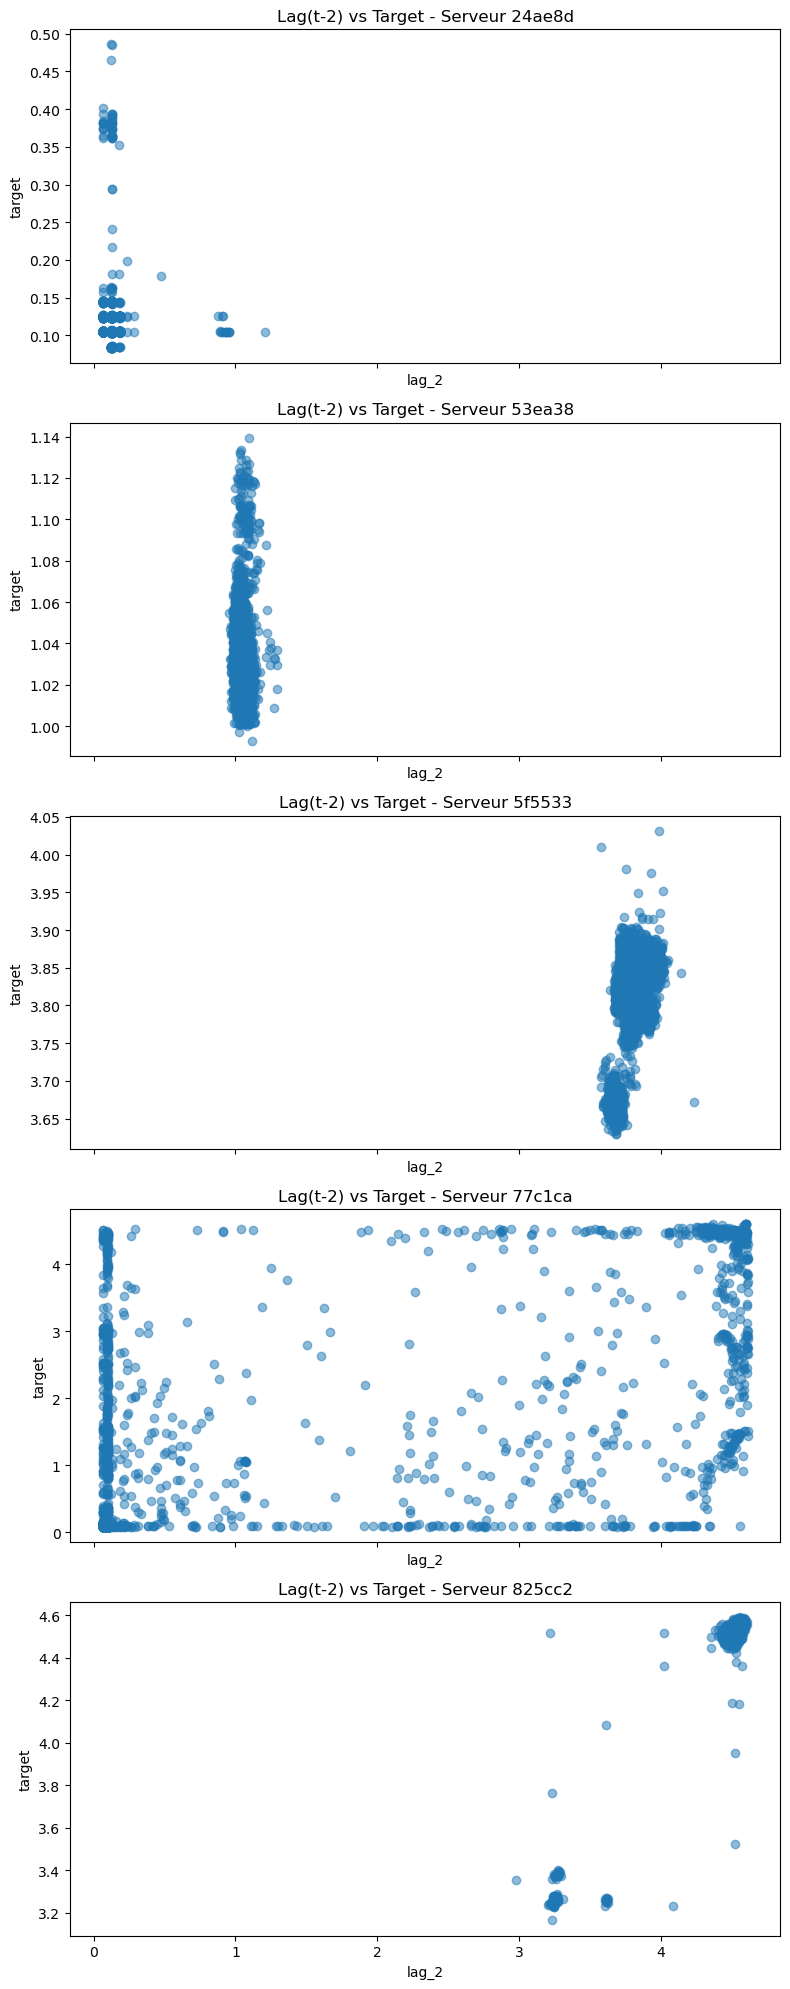

In [12]:
import matplotlib.pyplot as plt


servers = df_features['serveur_id'].unique()


n_servers = len(servers)
fig, axes = plt.subplots(n_servers, 1, figsize=(8, 4*n_servers), sharex=True)

if n_servers == 1:
    axes = [axes]

for ax, server_id in zip(axes, servers):
    df_server = df_features[df_features['serveur_id'] == server_id].dropna(subset=['lag_2', 'target'])
    
    ax.scatter(df_server['lag_2'], df_server['target'], alpha=0.5)
    ax.set_title(f"Lag(t-2) vs Target - Serveur {server_id}")
    ax.set_xlabel("lag_2")
    ax.set_ylabel("target")

plt.tight_layout()
plt.show()

>Corrélation entre passé et futur : Un scatter plot positif montre que la charge actuelle dépend fortement des mesures passées, justifiant l’utilisation de modèles de régression supervisée.

Rolling std: pour capturer la variabilité du cpu si l'ecart type est faible cpu stable et si l'ecart type est élevé cpu unstable 

In [13]:
df_features["rolling_std_5"] = df_features.groupby("serveur_id")["value_log"].transform(lambda x: x.rolling(5).std())
df_features.head(5)

,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_std_5
0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,NaN,0.123986,NaN,NaN,NaN,NaN,NaN
2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN
3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.125751,0.123986,NaN,NaN,NaN
4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398,NaN,0.125751,0.125751,0.125751,0.125751,NaN,NaN,0.000789


In [14]:
df_features["rolling_std_10"] = df_features.groupby("serveur_id")["value_log"].transform(lambda x: x.rolling(10).std())
df_features.head(5)

,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_std_5,rolling_std_10
0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,NaN,0.123986,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN,NaN
3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN
4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398,NaN,0.125751,0.125751,0.125751,0.125751,NaN,NaN,0.000789,NaN


 La Volatilité — Écart-type Mobile

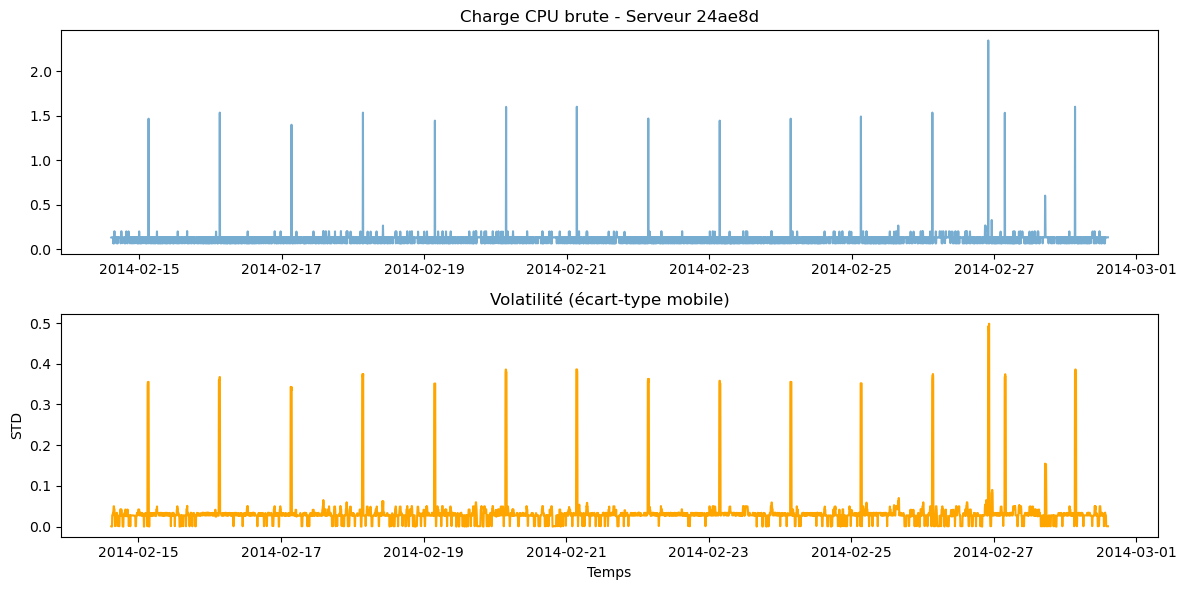

In [15]:
server_id = df_features['serveur_id'].unique()[0]
df_server = df_features[df_features['serveur_id'] == server_id]
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plt.plot(df_server['timestamp'], df_server['value'], label='CPU brute', alpha=0.6)
plt.title(f"Charge CPU brute - Serveur {server_id}")

plt.subplot(2,1,2)
plt.plot(df_server['timestamp'], df_server['rolling_std_5'], label='Écart-type mobile 5', color='orange')
plt.title("Volatilité (écart-type mobile)")
plt.xlabel("Temps")
plt.ylabel("STD")

plt.tight_layout()
plt.show()

>Volatilité : Les pics dans l’écart-type indiquent des périodes d’instabilité ou de turbulence du serveur.

Différence : permet de capturer les changements rapides et les pics soudains d'utilisation 

In [16]:
df_features["diff_1"] = df_features.groupby("serveur_id")["value_log"].diff(1)
df_features["diff_2"] = df_features.groupby("serveur_id")["value_log"].diff(2)
df_features.head(5)

,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_std_5,rolling_std_10,diff_1,diff_2
0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,NaN,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,0.001765,NaN
2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN,NaN,0.000000,0.001765
3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN,0.000000,0.000000
4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398,NaN,0.125751,0.125751,0.125751,0.125751,NaN,NaN,0.000789,NaN,0.000000,0.000000


 La Stationnarité — Différenciation

<Figure size 1200x600 with 0 Axes>

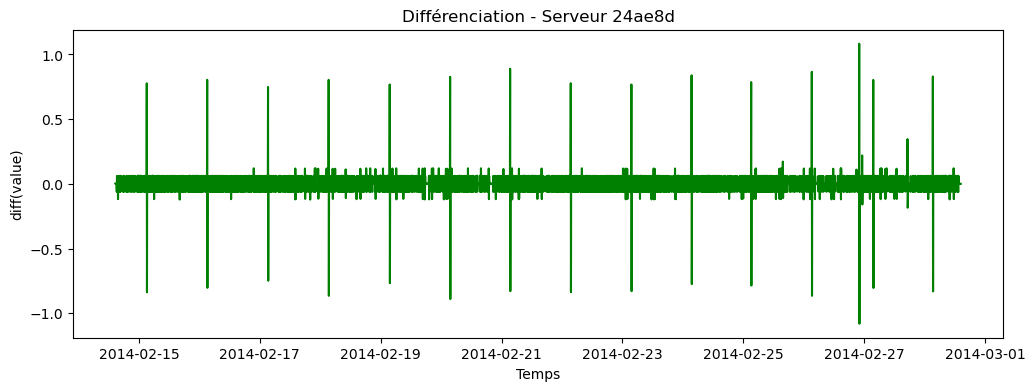

In [17]:
server_id = df_features['serveur_id'].unique()[0]
df_server = df_features[df_features['serveur_id'] == server_id]
plt.figure(figsize=(12,6))
plt.figure(figsize=(12,4))
plt.plot(df_server['timestamp'], df_server['diff_1'], color='green')
plt.title(f"Différenciation - Serveur {server_id}")
plt.xlabel("Temps")
plt.ylabel("diff(value)")
plt.show()

>Stationnarité : La différenciation supprime la tendance générale. Les écarts autour de zéro mettent en évidence les changements rapides à prédire.

Feature temporelle 
hour feature: pour capturer les patterns journaliers 
weekday feature:permet de capturer les patterns hebdomadaires

In [18]:
df_features = df_features.reset_index()
df_features ["hour"] = df_features["timestamp"].dt.hour
df_features["weekday"] = df_features["timestamp"].dt.weekday
df_features.head(5)

,index,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_std_5,rolling_std_10,diff_1,diff_2,hour,weekday
0,0,2014-02-14 14:30:00,0.132,24ae8d,0.132,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14,4
1,1,2014-02-14 14:35:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,NaN,0.123986,NaN,NaN,NaN,NaN,NaN,NaN,0.001765,NaN,14,4
2,2,2014-02-14 14:40:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN,NaN,0.000000,0.001765,14,4
3,3,2014-02-14 14:45:00,0.134,24ae8d,0.134,0.125751,NaN,NaN,0.125751,0.125751,0.125751,0.123986,NaN,NaN,NaN,NaN,0.000000,0.000000,14,4
4,4,2014-02-14 14:50:00,0.134,24ae8d,0.134,0.125751,0.125398,NaN,0.125751,0.125751,0.125751,0.125751,NaN,NaN,0.000789,NaN,0.000000,0.000000,14,4


Les Patterns Cycliques — Variables Temporelles & Resampling

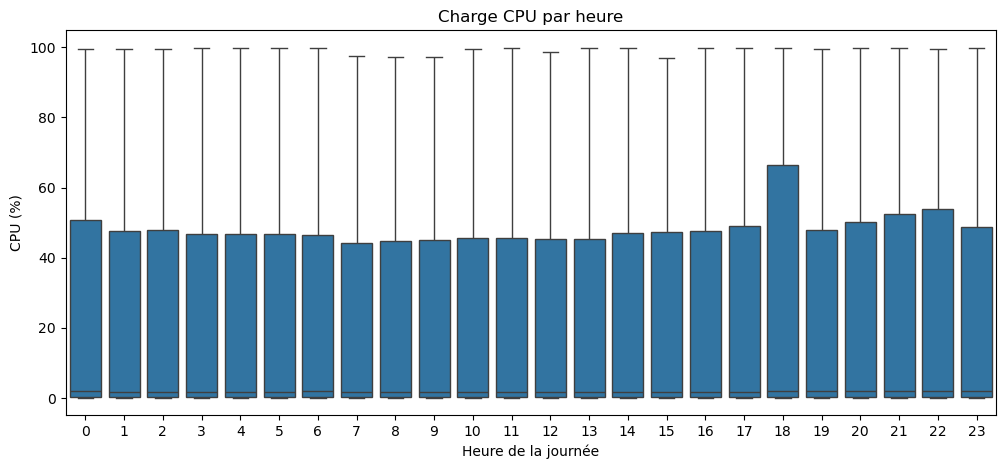

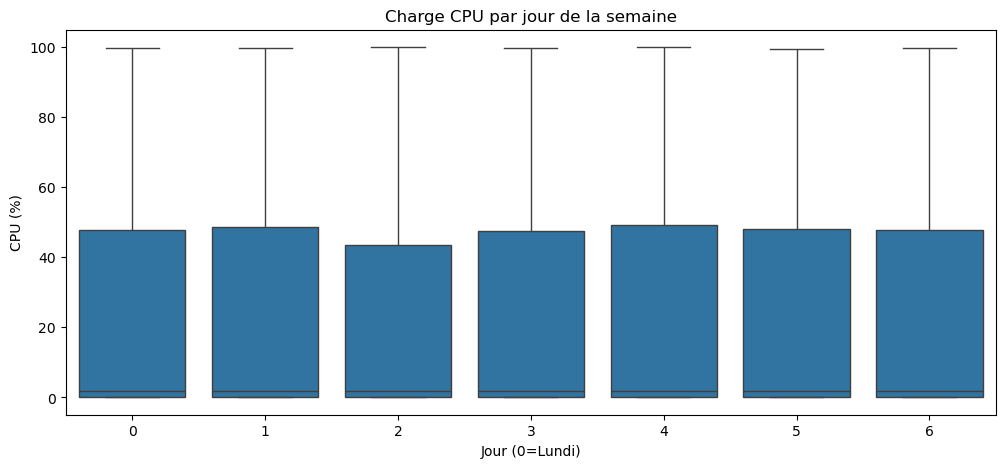

In [19]:
import seaborn as sns

# Boxplot par heure
plt.figure(figsize=(12,5))
sns.boxplot(x='hour', y='value', data=df_features)
plt.title("Charge CPU par heure")
plt.xlabel("Heure de la journée")
plt.ylabel("CPU (%)")
plt.show()

# Boxplot par jour de la semaine
plt.figure(figsize=(12,5))
sns.boxplot(x='weekday', y='value', data=df_features)
plt.title("Charge CPU par jour de la semaine")
plt.xlabel("Jour (0=Lundi)")
plt.ylabel("CPU (%)")
plt.show()

>Patterns cycliques : Les boxplots révèlent des variations récurrentes selon l’heure et le jour, ce qui peut guider la création de features temporelles.

Nettoyage final

In [20]:
df_features=df_features.dropna()
df_features.head(5)

,index,timestamp,value,serveur_id,value_filtered,value_log,moyenne_mobile_5,rolling_mean_10,target,lag_1,lag_2,lag_3,lag_5,lag_10,rolling_std_5,rolling_std_10,diff_1,diff_2,hour,weekday
10,10,2014-02-14 15:20:00,0.134,24ae8d,0.134,0.125751,0.113031,0.119391,0.104550,0.123986,0.063913,0.125751,0.125751,0.123986,0.027468,0.019501,0.001765,0.061838,15,4
11,11,2014-02-14 15:25:00,0.066,24ae8d,0.132,0.063913,0.100663,0.113207,0.104550,0.125751,0.123986,0.063913,0.125751,0.125751,0.033555,0.025986,-0.061838,-0.060073,15,4
12,12,2014-02-14 15:30:00,0.132,24ae8d,0.132,0.123986,0.100310,0.113031,0.123962,0.063913,0.125751,0.123986,0.125751,0.125751,0.033233,0.025897,0.060073,-0.001765,15,4
13,13,2014-02-14 15:35:00,0.202,24ae8d,0.132,0.183987,0.124325,0.118854,0.124587,0.123986,0.063913,0.125751,0.063913,0.125751,0.042460,0.034270,0.060001,0.120074,15,4
14,14,2014-02-14 15:40:00,0.068,24ae8d,0.068,0.065788,0.112685,0.112858,0.125175,0.183987,0.123986,0.063913,0.123986,0.125751,0.049901,0.037975,-0.118199,-0.058198,15,4


PARTIE ANOMALIES

In [21]:
df_original["diff"] = df_original.groupby("serveur_id")["value"].diff()

df_original["rolling_std"] = df_original.groupby("serveur_id")["value"] \
    .transform(lambda x: x.rolling(5).std())
df_original.head(5)

,value,serveur_id,diff,rolling_std
timestamp,,,,
2014-02-14 14:30:00,0.132,24ae8d,NaN,NaN
2014-02-14 14:35:00,0.134,24ae8d,0.002,NaN
2014-02-14 14:40:00,0.134,24ae8d,0.000,NaN
2014-02-14 14:45:00,0.134,24ae8d,0.000,NaN
2014-02-14 14:50:00,0.134,24ae8d,0.000,0.000894


Détection simple:le but est d'identifier les moments où le comportement du CPU devient anormalement instable
si la variabilité locale devient trop grande donc il y a probablement une anomalie.
Cette variabilité est mesurée avec rolling_std (écart-type mobile).
Cette limite est basée sur une règle statistique très utilisée. Règle des 3 écarts-types:Seuil = moyenne + 3 × écart-type

In [22]:
threshold = df_original["rolling_std"].mean() + 3 * df_original["rolling_std"].std()

df_original["anomaly"] = (df_original["rolling_std"] > threshold).astype(int)

Préparation de la validation

In [23]:
from sklearn.model_selection import TimeSeriesSplit

X = df_features.drop(columns=["target", "timestamp"])
y = df_features["target"]

tscv = TimeSeriesSplit(n_splits=5)

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"Split {i+1}")
    print(f"Train size: {len(train_index)}")
    print(f"Test size: {len(test_index)}")
    print(f"Train index range: {train_index[0]} → {train_index[-1]}")
    print(f"Test index range: {test_index[0]} → {test_index[-1]}")
    print("-" * 40)

Split 1
Train size: 3355
Test size: 3350
Train index range: 0 → 3354
Test index range: 3355 → 6704
----------------------------------------
Split 2
Train size: 6705
Test size: 3350
Train index range: 0 → 6704
Test index range: 6705 → 10054
----------------------------------------
Split 3
Train size: 10055
Test size: 3350
Train index range: 0 → 10054
Test index range: 10055 → 13404
----------------------------------------
Split 4
Train size: 13405
Test size: 3350
Train index range: 0 → 13404
Test index range: 13405 → 16754
----------------------------------------
Split 5
Train size: 16755
Test size: 3350
Train index range: 0 → 16754
Test index range: 16755 → 20104
----------------------------------------


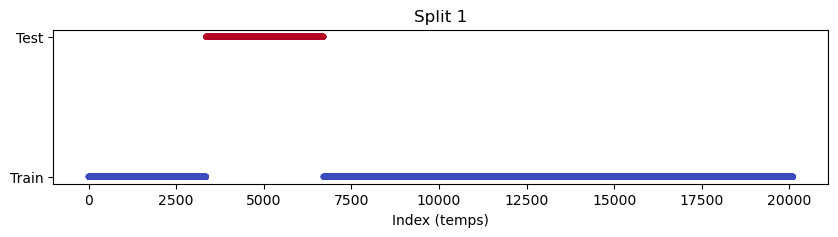

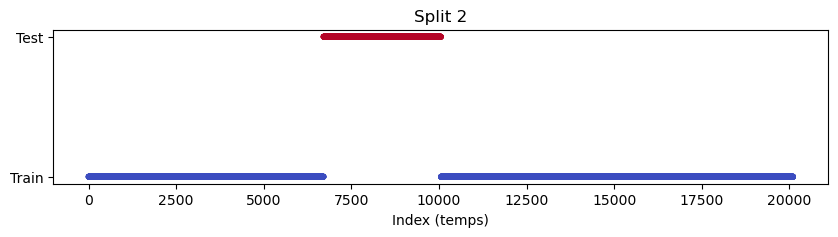

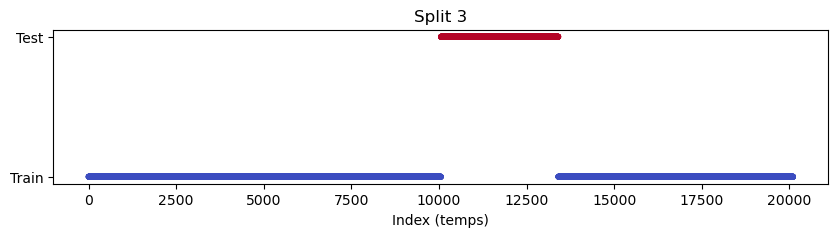

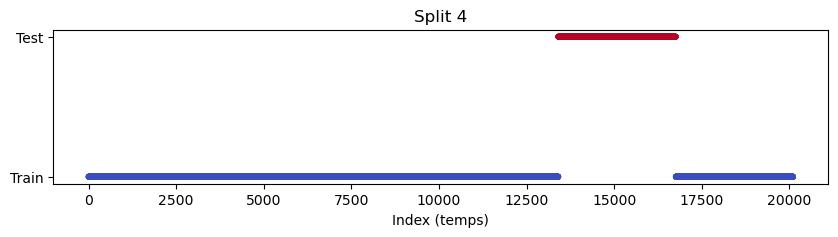

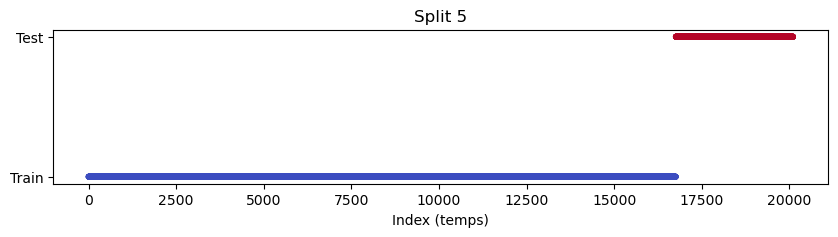

In [24]:
import matplotlib.pyplot as plt
import numpy as np

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    split_visual = np.zeros(len(X))
    split_visual[train_index] = 0
    split_visual[test_index] = 1

    plt.figure(figsize=(10, 2))
    plt.scatter(range(len(X)), split_visual, c=split_visual, cmap='coolwarm', s=10)
    plt.title(f"Split {i+1}")
    plt.yticks([0, 1], ["Train", "Test"])
    plt.xlabel("Index (temps)")
    plt.show()

Dans ce projet, nous avons utilisé la méthode TimeSeriesSplit pour effectuer une validation adaptée aux données temporelles.
Chaque split est construit de manière chronologique :
- le jeu d'entraînement contient les observations passées
- le jeu de test contient des observations futures
Au fur et à mesure des splits, la taille du jeu d'entraînement augmente, permettant au modèle d’apprendre sur un historique de plus en plus riche.
Cette approche permet d’éviter toute fuite de données (data leakage) et garantit une évaluation réaliste des performances du modèle dans un contexte de prédiction temporelle.

In [25]:
df_features.to_csv("df_features_ready.csv", index=False)

In [26]:
df_original.to_csv("df_original_ready.csv", index=False)